/home/scratch/ipykernel_3635925/2265494495.py:104: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['AgeGroup'] = df[age_col].apply(parse_age_group)


Detected Age Categories (2 classes): ['31 and Above' 'Below 31']


Reading NIfTI Files from Disk: 100%|██████████| 897/897 [01:35<00:00,  9.36it/s]


Extracting High-Res Spectral Tokens (4^3 blocks x 4^3 freqs = 4096 features)...


Block-DCT Extraction: 100%|██████████| 100/100 [00:09<00:00, 10.79it/s]


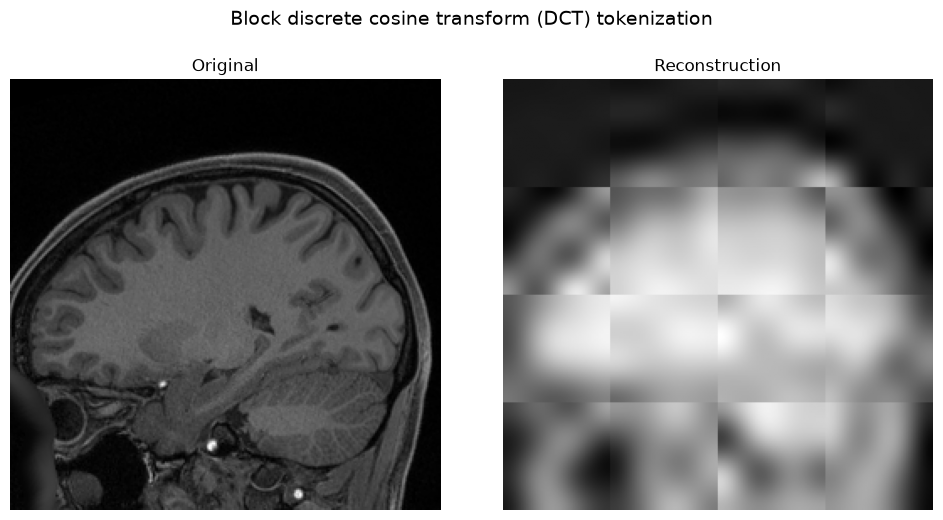


 TRAINING ON FULL DATASET (100 samples) - 5-FOLD CV 
Fold 0 | SpectralViT (Block-DCT)        | Params: 21,216 | Acc: 75.00% | F1: 0.7442 | AUC: 0.7396
Fold 0 | LogisticRegression (Block-DCT) | Params: 4,097 | Acc: 60.00% | F1: 0.3750 | AUC: 0.5000
Fold 0 | MLP (Block-DCT)                | Params: 24,589 | Acc: 75.00% | F1: 0.7151 | AUC: 0.5938
Fold 0 | SpatialViT (Micro)             | Params: 27,169 | Acc: 60.00% | F1: 0.3750 | AUC: 0.3229
Fold 0 | AttnUNet (Micro)               | Params: 18,724 | Acc: 40.00% | F1: 0.4000 | AUC: 0.2708
Fold 0 | Swin (Micro)                   | Params: 19,457 | Acc: 50.00% | F1: 0.4505 | AUC: 0.3750
Fold 1 | SpectralViT (Block-DCT)        | Params: 21,216 | Acc: 55.00% | F1: 0.5489 | AUC: 0.5312
Fold 1 | LogisticRegression (Block-DCT) | Params: 4,097 | Acc: 55.00% | F1: 0.5489 | AUC: 0.4896
Fold 1 | MLP (Block-DCT)                | Params: 24,589 | Acc: 65.00% | F1: 0.6267 | AUC: 0.4375
Fold 1 | SpatialViT (Micro)             | Params: 27,169 | Acc: 55

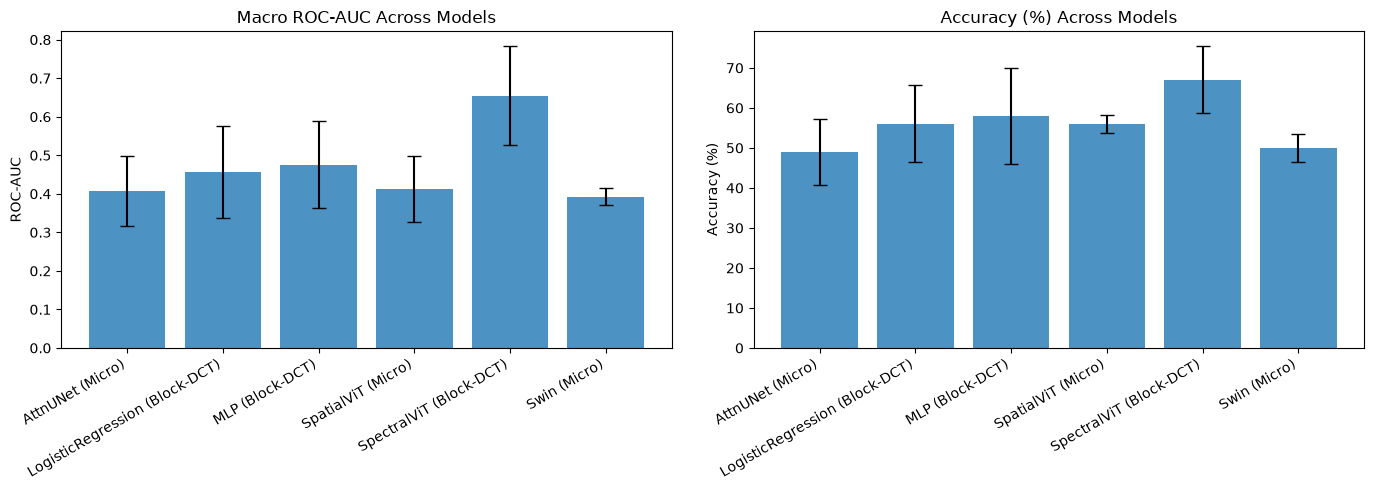

In [2]:
# %% [Multi-Moment Spectral Envelopes: Age Category Classification on HCP] 
import os 
import re 
import time 
import copy 
import warnings 
import numpy as np 
import pandas as pd 
import nibabel as nib 
import torch 
import torch.nn as nn 
import torch.optim as optim 
from torch.optim.lr_scheduler import OneCycleLR 
from torch.utils.data import DataLoader, TensorDataset 
from sklearn.model_selection import StratifiedKFold 
from sklearn.preprocessing import LabelEncoder 
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, roc_auc_score 
import scipy.stats as stats 
import scipy.fft as fft 
from tqdm import tqdm 
import gc 
import matplotlib.pyplot as plt 

# Import classes from your local networks.py 
from util import seed_everything, count_parameters 
from networks import SpectralViT, SpatialViT, AttentionUNet, SwinTransformer, LogisticRegression, MultiLayerPerceptron 

# --- Config --- 
warnings.filterwarnings("ignore", category=UserWarning) 
HCP_DIR = '/autofs/vast/lemon/data_instantsurfer_uncurated/HCP' 
TSV_PATH = os.path.join(HCP_DIR, 'participants.tsv') 

VOL_SIZE = 256 
EPOCHS = 500 
N_FOLDS = 5 
UNIFIED_LR = 1e-3 
FORCE_RECACHE = True 

CACHE_DIR = os.path.expanduser('/autofs/space/cadiz_001/users/ar1326/SpectralViT/data/cache/') 
os.makedirs(CACHE_DIR, exist_ok=True) 
SPATIAL_CACHE_PATH = os.path.join(CACHE_DIR, f'hcp_spatial_cache_vol{VOL_SIZE}.npz') 

RUN_ID = time.strftime("%Y%m%d_%H%M%S") 
OUTPUT_DIR = os.path.expanduser(f'~/SpectralViT/results/hcp_age_classification_{RUN_ID}') 
os.makedirs(OUTPUT_DIR, exist_ok=True) 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
seed_everything(0) 

# %% [Classification Wrapper] 
class ClassificationWrapper(nn.Module): 
    """Dynamically wraps regression or feature-extractor networks for multi-class classification.""" 
    def __init__(self, base_model, num_classes): 
        super().__init__() 
        self.base_model = base_model 
        self.num_classes = num_classes 
        self.classifier = None 

    def forward(self, x): 
        out = self.base_model(x) 
        if out.ndim > 2: 
            out = out.mean(dim=1) 
        elif out.ndim == 1: 
            out = out.unsqueeze(1) 

        if out.shape[1] == self.num_classes: 
            return out 

        if self.classifier is None or self.classifier.in_features != out.shape[1]: 
            self.classifier = nn.Linear(out.shape[1], self.num_classes).to(out.device) 
        return self.classifier(out) 


def load_raw_hcp_spatial(hcp_dir, tsv_path, vol_size=96): 
    try: 
        df = pd.read_csv(tsv_path, sep='\t') 
    except Exception: 
        df = pd.read_csv(tsv_path, sep=r'\s+') 

    age_col = [c for c in df.columns if 'AGE' in c.upper()][0] 
    df = df.dropna(subset=[age_col]) 


    def parse_age_group(age_str): 
        age_str = str(age_str).strip() 
        # Direct string mapping for HCP groups 
        if age_str in ['22-25', '26-30']: 
            return 'Below 31' 
        elif age_str in ['31-35', '36+']: 
            return '31 and Above' 

        try: 
            if '-' in age_str: 
                val = float(age_str.split('-')[0]) 
            elif '+' in age_str: 
                val = float(age_str.replace('+', '')) 
            else: 
                val = float(age_str) 
                 
            return 'Below 31' if val < 31 else '31 and Above' 
        except: 
            return None 

    df['AgeGroup'] = df[age_col].apply(parse_age_group) 
    df = df.dropna(subset=['AgeGroup']) 
     
    raw_ages = df['AgeGroup'].values 
    le = LabelEncoder() 
    encoded_ages = le.fit_transform(raw_ages) 
    class_names = le.classes_ 
    print(f"Detected Age Categories ({len(class_names)} classes): {class_names}") 

    subject_to_label = {} 
    for col in df.columns: 
        if 'subject' in col.lower() or 'id' in col.lower(): 
            for sub_val, lbl in zip(df[col].astype(str), encoded_ages): 
                sub_str = sub_val.strip() 
                subject_to_label[sub_str] = lbl 
                clean_sub = re.sub(r'^sub[_-]?', '', sub_str, flags=re.IGNORECASE).strip() 
                if clean_sub: 
                    subject_to_label[clean_sub] = lbl 

    nifti_files = [] 
    for root, _, files in os.walk(hcp_dir): 
        for f in files: 
            if f.endswith(('.nii', '.nii.gz')) and 't1w' in f.lower(): 
                nifti_files.append(os.path.join(root, f)) 

    vols, labels = [], [] 
    for fpath in tqdm(sorted(nifti_files), desc="Reading NIfTI Files from Disk"): 
        matched_id = None 
        sub_match = re.search(r'sub-([a-zA-Z0-9]+)', fpath, re.IGNORECASE) 
        if sub_match: 
            candidate = sub_match.group(1) 
            if candidate in subject_to_label: matched_id = candidate 
            elif f"sub-{candidate}" in subject_to_label: matched_id = f"sub-{candidate}" 

        if matched_id is None: 
            for key in subject_to_label: 
                if len(key) >= 2 and key in fpath: 
                    matched_id = key 
                    break 
        if matched_id is None: continue 

        try: img = nib.load(fpath).get_fdata() 
        except Exception: continue 

        c = np.array(img.shape) // 2 
        r = vol_size // 2 

        if any(s < vol_size for s in img.shape): 
            pad_x = max(0, vol_size - img.shape[0]) 
            pad_y = max(0, vol_size - img.shape[1]) 
            pad_z = max(0, vol_size - img.shape[2]) 
            img = np.pad(img, ((0, pad_x), (0, pad_y), (0, pad_z)), mode='constant') 
            c = np.array(img.shape) // 2 

        crop = img[c[0]-r:c[0]+r, c[1]-r:c[1]+r, c[2]-r:c[2]+r] 
        if crop.shape == (vol_size, vol_size, vol_size): 
            std_val = np.std(crop) 
            norm_crop = (crop - np.mean(crop)) / (std_val if std_val > 1e-8 else 1.0) 
            vols.append(norm_crop) 
            labels.append(subject_to_label[matched_id]) 

    return np.array(vols, dtype=np.float32), np.array(labels, dtype=np.int64), class_names 

if os.path.exists(SPATIAL_CACHE_PATH) and not FORCE_RECACHE: 
    cached_data = np.load(SPATIAL_CACHE_PATH, allow_pickle=True) 
    X, Y, CLASS_NAMES = cached_data['X'], cached_data['Y'], cached_data['CLASS_NAMES'] 
else: 
    X, Y, CLASS_NAMES = load_raw_hcp_spatial(HCP_DIR, TSV_PATH, VOL_SIZE) 
    np.savez_compressed(SPATIAL_CACHE_PATH, X=X, Y=Y, CLASS_NAMES=CLASS_NAMES) 

NUM_CLASSES = len(CLASS_NAMES) 


def extract_block_dct(vols, grid_size=4, keep_freqs=4): 
    """ 
    MACRO-TOKENS, MICRO-RESOLUTION: 4x4x4 Grid = 64 Tokens. 
    By keeping 4x4x4 frequencies per block, we capture deep structural textures. 
    64 blocks * 64 freqs = 4,096 continuous features mapped perfectly to 64 ViT patches! 
    """ 
    B, D, H, W = vols.shape 
    bz, by, bx = D // grid_size, H // grid_size, W // grid_size 
    n_blocks = grid_size ** 3 
    features_per_block = keep_freqs ** 3 

    print(f"Extracting High-Res Spectral Tokens ({grid_size}^3 blocks x {keep_freqs}^3 freqs = {n_blocks * features_per_block} features)...") 
    all_features = np.zeros((B, n_blocks, features_per_block), dtype=np.float32) 

    for i in tqdm(range(B), desc="Block-DCT Extraction"): 
        vol = vols[i] 
        block_idx = 0 
        for z in range(grid_size): 
            for y in range(grid_size): 
                for x in range(grid_size): 
                    block = vol[z*bz:(z+1)*bz, y*by:(y+1)*by, x*bx:(x+1)*bx] 
                    dct_block = fft.dctn(block, type=2, norm='ortho') 
                    low_freq = dct_block[:keep_freqs, :keep_freqs, :keep_freqs].flatten() 
                    all_features[i, block_idx, :] = np.sign(low_freq) * np.log1p(np.abs(low_freq)) 
                    block_idx += 1 

    return all_features.reshape(B, -1) 


X_spectral_raw = extract_block_dct(X, grid_size=4, keep_freqs=4) 

def compute_multiclass_auc(y_true, y_prob): 
    """Shared helper -- one-vs-rest macro AUC logic.""" 
    try: 
        present_classes = np.unique(y_true) 
        aucs = [roc_auc_score((y_true == c).astype(int), y_prob[:, c]) 
                for c in present_classes if len(np.unique((y_true == c).astype(int))) > 1] 
        return np.mean(aucs) if aucs else float('nan') 
    except Exception: 
        return float('nan') 

def visualize_block_tokens(vols, features_raw, grid_size=4, keep_freqs=4, sample_idx=0): 
    vol = vols[sample_idx] 
    feats = features_raw[sample_idx].reshape((grid_size, grid_size, grid_size, keep_freqs, keep_freqs, keep_freqs)) 
    feats_unlogged = np.sign(feats) * np.expm1(np.abs(feats)) 
    reconstructed_vol = np.zeros_like(vol) 
    bz, by, bx = vol.shape[0]//grid_size, vol.shape[1]//grid_size, vol.shape[2]//grid_size 

    for z in range(grid_size): 
        for y in range(grid_size): 
            for x in range(grid_size): 
                padded_freq = np.zeros((bz, by, bx)) 
                padded_freq[:keep_freqs, :keep_freqs, :keep_freqs] = feats_unlogged[z, y, x] 
                reconstructed_vol[z*bz:(z+1)*bz, y*by:(y+1)*by, x*bx:(x+1)*bx] = fft.idctn(padded_freq, type=2, norm='ortho') 

    mid_block_z = grid_size // 2 
    z_vol = (mid_block_z * bz) - (bz // 2) 

    fig, axes = plt.subplots(1, 2, figsize=(10, 5)) 
    axes[0].imshow(np.rot90(vol[z_vol, :, :],k=-1), cmap='gray', origin='lower') 
    axes[0].set_title("Original", fontsize=12) 
    axes[0].axis('off') 

    axes[1].imshow(np.rot90(reconstructed_vol[z_vol, :, :],k=-1), cmap='gray', origin='lower') 
    axes[1].set_title("Reconstruction", fontsize=12) 
    axes[1].axis('off') 

    plt.suptitle("Block discrete cosine transform (DCT) tokenization", fontsize=14, y=1.03) 
    plt.tight_layout() 
    plt.show() 

# Run the visualization on the first subject prior to training 
visualize_block_tokens(X, X_spectral_raw, grid_size=4, keep_freqs=4, sample_idx=0) 

# %% [Unified Training Function] 
def train_model_full(model, train_loader, val_data, num_classes, epochs, lr, device, model_name, class_weights=None): 
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05) 
    scheduler = OneCycleLR(optimizer, max_lr=lr, steps_per_epoch=len(train_loader), epochs=epochs) 

    # Standard CrossEntropyLoss without label smoothing 
    criterion = nn.CrossEntropyLoss(weight=class_weights) 

    best_f1, best_state, patience, trigger = -1.0, None, 40, 0 

    for epoch in range(1, epochs + 1): 
        model.train() 
        for b_x, b_y in train_loader: 
            b_x, b_y = b_x.to(device), b_y.to(device, dtype=torch.long) 
            optimizer.zero_grad() 
            output = model(b_x) 
            loss = criterion(output, b_y) 
            if not torch.isfinite(loss): continue 
            loss.backward() 
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) 
            optimizer.step(); scheduler.step() 

        if epoch % 10 == 0: 
            model.eval() 
            with torch.no_grad(): 
                v_x, v_y = val_data 
                v_x_dev = v_x.to(device) 

                p = model(v_x_dev) if v_x_dev.ndim < 5 else torch.cat([model(c.to(device)) for c in torch.split(v_x_dev, 2)]) 
                p_cls = torch.argmax(p, dim=1).cpu().numpy() 
                cur_f1 = f1_score(v_y, p_cls, average='macro', zero_division=0) 
                if cur_f1 > best_f1: 
                    best_f1, best_state, trigger = cur_f1, copy.deepcopy(model.state_dict()), 0 
                else: 
                    trigger += 1 
                if trigger >= (patience // 10): break 

    if best_state is not None: model.load_state_dict(best_state) 
    model.eval() 
    with torch.no_grad(): 
        v_x, v_y = val_data 
        v_x_dev = v_x.to(device) 
        p = model(v_x_dev) if v_x_dev.ndim < 5 else torch.cat([model(c.to(device)) for c in torch.split(v_x_dev, 2)]) 
        p_prob = torch.softmax(p, dim=1).cpu().numpy() 
        p_cls = np.argmax(p_prob, axis=1) 

        auc = compute_multiclass_auc(v_y, p_prob) 

        return {'Accuracy': accuracy_score(v_y, p_cls), 'Macro_F1': f1_score(v_y, p_cls, average='macro', zero_division=0), 'Balanced_Acc': balanced_accuracy_score(v_y, p_cls), 'AUC': auc} 

# %% [Main Experiment Loop] 
results = [] 
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=0) 
GLOBAL_BATCH_SIZE = 4 

print(f"\n==================================================") 
print(f" TRAINING ON FULL DATASET ({len(X)} samples) - 5-FOLD CV ") 
print(f"==================================================") 

for fold, (train_idx, test_idx) in enumerate(skf.split(X, Y)): 
    gc.collect(); torch.cuda.empty_cache() 

    sub_idx = np.array(train_idx, copy=True) 
    test_idx = np.array(test_idx, copy=True) 
    y_train_tensor = torch.from_numpy(Y[sub_idx]).long() 

    counts = np.bincount(Y[sub_idx], minlength=NUM_CLASSES) 
    total_samples = len(Y[sub_idx]) 
    n_classes_present = np.count_nonzero(counts) 

    weights = np.zeros(NUM_CLASSES, dtype=np.float32) 
    for c in range(NUM_CLASSES): 
        weights[c] = total_samples / (n_classes_present * counts[c]) if counts[c] > 0 else 0.0 
    class_weights = torch.tensor(weights, dtype=torch.float).to(device) 

    sm, ss = X_spectral_raw[sub_idx].mean(axis=0), X_spectral_raw[sub_idx].std(axis=0) + 1e-8 
    tr_s = torch.from_numpy((X_spectral_raw[sub_idx] - sm) / ss).float() 
    ts_s = torch.from_numpy((X_spectral_raw[test_idx] - sm) / ss).float() 
    tr_v, ts_v = torch.from_numpy(X[sub_idx]).unsqueeze(1).float(), torch.from_numpy(X[test_idx]).unsqueeze(1).float() 

    def build_spectral(): 
        # High-Res Macro Tokens configuration: 
        # 4096 inputs / 64 patch_size = exactly 64 structural tokens. 
        net = SpectralViT( 
            n_inputs=4096, 
            patch_size=64, 
            embed_dim=32, 
            n_layers=2, 
            n_heads=2, 
            use_rank_weights=False, 
            use_pos_embed=False   # Stop parameter bloat 
        ) 
        # Inject precise positional embeddings for 64 sequence length 
        net.use_pos_embed = True 
        net.pos_embed = nn.Parameter(torch.randn(64, 1, 32) * 0.02) 
        net.mlp_head = nn.Identity() 
        return net 

    models = [ 
        ("SpectralViT (Block-DCT)", build_spectral, tr_s, ts_s), 
        ("LogisticRegression (Block-DCT)", lambda: LogisticRegression(in_features=4096), tr_s, ts_s),
        ("MLP (Block-DCT)", lambda: MultiLayerPerceptron(input_dim=4096, hidden_dim=6), tr_s, ts_s),
        ("SpatialViT (Micro)", lambda: SpatialViT(vol_size=32, patch_size=8, embed_dim=32, n_layers=1, n_heads=2), 
         torch.nn.functional.interpolate(tr_v, size=32), torch.nn.functional.interpolate(ts_v, size=32)), 
        ("AttnUNet (Micro)", lambda: AttentionUNet(in_channels=1, base_channels=8), tr_v, ts_v), 
        ("Swin (Micro)", lambda: SwinTransformer(img_size=VOL_SIZE,window_size=8),  
         torch.nn.functional.interpolate(tr_v, size=VOL_SIZE),  
         torch.nn.functional.interpolate(ts_v, size=VOL_SIZE)) 
    ] 

    for name, build_fn, x_tr, x_ts in models: 
        base_net = build_fn() 
        model = ClassificationWrapper(base_net, num_classes=NUM_CLASSES).to(device) 
        p_count = count_parameters(model) 

        loader = DataLoader(TensorDataset(x_tr, y_train_tensor), batch_size=GLOBAL_BATCH_SIZE, shuffle=True) 

        res = train_model_full(model, loader, (x_ts, Y[test_idx]), NUM_CLASSES, EPOCHS, UNIFIED_LR, device, name, class_weights) 

        print(f"Fold {fold} | {name:<30} | Params: {p_count:,} | Acc: {res['Accuracy']*100:.2f}% | F1: {res['Macro_F1']:.4f} | AUC: {res['AUC']:.4f}") 
        res.update({'Fold': fold, 'Model': name, 'Params': p_count}) 
        results.append(res) 

        pd.DataFrame(results).to_csv(os.path.join(OUTPUT_DIR, 'classification_results.csv'), index=False) 
        del model; del base_net; del loader; gc.collect(); torch.cuda.empty_cache() 

# %% [Statistical Significance] 
print(f"\n==================================================") 
print(f" STATISTICAL SIGNIFICANCE (Paired t-test Across Folds) ") 
print(f"==================================================") 
full_df = pd.DataFrame(results) 
baseline_model = "SpectralViT (Block-DCT)" 
metrics = ['Accuracy', 'Macro_F1', 'Balanced_Acc', 'AUC'] 
other_models = [m for m in full_df['Model'].unique() if m != baseline_model] 

for other in other_models: 
    print(f"\n--- Comparing {baseline_model} vs {other} ---") 
    base_data = full_df[full_df['Model'] == baseline_model].sort_values('Fold') 
    other_data = full_df[full_df['Model'] == other].sort_values('Fold') 

    for metric in metrics: 
        x_vals = base_data[metric].values 
        y_vals = other_data[metric].values 
        if len(x_vals) == len(y_vals) and len(x_vals) > 1: 
            mask = ~np.isnan(x_vals) & ~np.isnan(y_vals) 
            if np.sum(mask) > 1: 
                t_stat, p_val = stats.ttest_rel(x_vals[mask], y_vals[mask], alternative='greater')
                mean_diff = np.mean(x_vals[mask] - y_vals[mask]) 

                print(f"  {metric:<15} | Mean Diff: {mean_diff:+.4f} | t-stat: {t_stat:6.4f} | p-val: {p_val:6.4f} {'*' if p_val < 0.05 else ''}") 

# %% [Visualization] 
summary = full_df.groupby('Model')[['Accuracy', 'Macro_F1', 'Balanced_Acc', 'AUC']].agg(['mean', 'std']) 
print("\n--- Summary Performance Across 5 Folds ---") 
print(summary) 

fig, axes = plt.subplots(1, 2, figsize=(14, 5)) 

mean_auc, std_auc = full_df.groupby('Model')['AUC'].mean(), full_df.groupby('Model')['AUC'].std() 
axes[0].bar(mean_auc.index, mean_auc.values, yerr=std_auc.values, capsize=5, alpha=0.8) 
axes[0].set_title("Macro ROC-AUC Across Models") 
axes[0].set_ylabel("ROC-AUC") 
axes[0].set_xticklabels(mean_auc.index, rotation=30, ha='right') 

mean_acc, std_acc = full_df.groupby('Model')['Accuracy'].mean() * 100, full_df.groupby('Model')['Accuracy'].std() * 100 
axes[1].bar(mean_acc.index, mean_acc.values, yerr=std_acc.values, capsize=5, alpha=0.8) 
axes[1].set_title("Accuracy (%) Across Models") 
axes[1].set_ylabel("Accuracy (%)") 
axes[1].set_xticklabels(mean_acc.index, rotation=30, ha='right') 

plt.tight_layout() 
plt.savefig(os.path.join(OUTPUT_DIR, 'model_performance_comparison.png'), dpi=300) 
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from IPython.display import display

full_df = pd.DataFrame(results)

baseline = "SpectralViT (Block-DCT)"

display_names = {
    "SpectralViT (Block-DCT)": "Spectral ViT (proposed)",
    "LogisticRegression (Block-DCT)": "Spectral LR",
    "MLP (Block-DCT)": "Spectral MLP",
    "SpatialViT (Micro)": "Spatial ViT",
    "AttnUNet (Micro)": "Attention U-Net",
    "Swin (Micro)": "Swin Transformer",
}

metric_map = {
    "AUC": "AUC",
    "Accuracy": "Accuracy",
    "Balanced_Acc": "Specificity",
    "Macro_F1": "F1",
}

order = [
    baseline,
    "LogisticRegression (Block-DCT)",
    "MLP (Block-DCT)",
    "SpatialViT (Micro)",
    "AttnUNet (Micro)",
    "Swin (Micro)",
]

# ---------------- Significance ----------------

stars = {m: {k: False for k in metric_map} for m in full_df.Model.unique()}

base = full_df[full_df.Model == baseline].sort_values("Fold")

for model in order:
    if model == baseline:
        continue

    other = full_df[full_df.Model == model].sort_values("Fold")

    for metric in metric_map:

        _, p = stats.ttest_rel(
            base[metric].values,
            other[metric].values,
            alternative="greater",
        )

        stars[model][metric] = p < 0.05

# ---------------- Table ----------------

rows = []

for model in order:

    row = {"Model": display_names[model]}

    df = full_df[full_df.Model == model]

    for metric, name in metric_map.items():

        mean = df[metric].mean()
        std = df[metric].std()

        cell = f"{mean:.2f} ± {std:.2f}"

        if stars[model][metric]:
            cell += "*"

        row[name] = cell

    rows.append(row)

table = pd.DataFrame(rows)

# ---------------- Display ----------------

display(
    table.style
    .hide(axis="index")
    .set_caption("HCP Results (5-fold cross-validation)")
    .set_table_styles([
        {"selector":"caption",
         "props":[("font-size","16px"),
                  ("font-weight","bold"),
                  ("text-align","center")]},
        {"selector":"th",
         "props":[("text-align","center"),
                  ("font-weight","bold")]},
        {"selector":"td",
         "props":[("text-align","center")]},
    ])
    .set_properties(subset=["Model"], **{
        "text-align":"left",
        "font-weight":"bold"
    })
)

Model,AUC,Accuracy,Specificity,F1
Spectral ViT (proposed),0.65 ± 0.13,0.67 ± 0.08,0.67 ± 0.08,0.66 ± 0.08
Spectral LR,0.46 ± 0.12*,0.56 ± 0.10*,0.55 ± 0.09*,0.48 ± 0.15*
Spectral MLP,0.48 ± 0.11*,0.58 ± 0.12,0.57 ± 0.10,0.52 ± 0.16
Spatial ViT,0.41 ± 0.09*,0.56 ± 0.02*,0.51 ± 0.03*,0.45 ± 0.09*
Attention U-Net,0.41 ± 0.09*,0.49 ± 0.08*,0.48 ± 0.06*,0.46 ± 0.05*
Swin Transformer,0.39 ± 0.02*,0.50 ± 0.04*,0.50 ± 0.03*,0.43 ± 0.07*
